In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.width",None)

In [2]:
def find_true_probabilities_equal(odds):
    probabilities = [1/o for o in odds]
    total_probability = sum(probabilities)
    overround = total_probability - 1
    adjustment_factor = overround / len(odds)
    adjusted_probabilities = [(1/o) - adjustment_factor for o in odds]
    return np.array(adjusted_probabilities)


In [3]:
season_list = ['1617', '1718', '1819', '1920', '2021', '2122', '2223', '2324', '2425']

league_list = ['E0', 'E1', 'E2', 'E3', 'SC0', 'SC1', 'SC2', 'D1', 'D2', 'I1', 'I2', 'SP1', 'SP2', 'F1', 'F2', 'N1', 'B1', 'P1', 'T1', 'G1']  

df_list = []
for league in league_list:
    for season in season_list:
        data_url = f'https://www.football-data.co.uk/mmz4281/{season}/{league}.csv'
        try:
            df = pd.read_csv(data_url)
        except:
            df = pd.read_csv(data_url, encoding='latin')
        df_list.append(df)

main_df = pd.concat(df_list)

main_df['Date'] = pd.to_datetime(main_df['Date'], format='mixed')

main_df = main_df.sort_values(by='Date')

bookmakers = ['B365', 'BW', 'IW', 'PS', 'WH', 'VC']

home_cols = []
draw_cols = []
away_cols = []

for book in bookmakers:
    home_col = book + 'H'
    home_cols.append(home_col)
    draw_col = book + 'D'
    draw_cols.append(draw_col)
    away_col = book + 'A'
    away_cols.append(away_col)

main_df['home_max_odds'] = main_df[home_cols].max(axis=1)
main_df['draw_max_odds'] = main_df[draw_cols].max(axis=1)
main_df['away_max_odds'] = main_df[away_cols].max(axis=1)

main_df.reset_index(inplace=True)

col_list = ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'PSH', 'PSD', 'PSA', 'home_max_odds', 'draw_max_odds', 'away_max_odds']

main_df = main_df[col_list]


C:\Users\mikko\AppData\Local\Temp\ipykernel_23228\2168323404.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  main_df['home_max_odds'] = main_df[home_cols].max(axis=1)
C:\Users\mikko\AppData\Local\Temp\ipykernel_23228\2168323404.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  main_df['draw_max_odds'] = main_df[draw_cols].max(axis=1)
C:\Users\mikko\AppData\Local\Temp\ipykernel_23228\2168323404.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whic

In [4]:
main_df = main_df[~main_df['PSH'].isna()]

main_df.reset_index(inplace=True)

In [5]:
main_df[['pinnacle_true_home_prob', 'pinnacle_true_draw_prob', 'pinnacle_true_away_prob']] = main_df.apply(
    lambda row: find_true_probabilities_equal([row['PSH'], row['PSD'], row['PSA']]),
    axis=1,
    result_type='expand'
)

main_df['totes'] = main_df['pinnacle_true_home_prob'] + main_df['pinnacle_true_draw_prob'] + main_df['pinnacle_true_away_prob']

tolerance = 1e-7
mask = np.abs(main_df['totes'] -1 <= tolerance)

assert len(main_df[~mask]) == 0

len(main_df[~mask])

0

In [6]:
def calculate_ev_from_odds(bookmaker_odds, our_probability):
    payout = bookmaker_odds
    ev = (our_probability * payout) -1
    return ev

In [7]:
assert calculate_ev_from_odds(2.0, 0.5) == 0

In [8]:
calculate_ev_from_odds(3.0, 0.5)

0.5

In [9]:
def calculate_kelly_stake(bankroll, ev, odds, kelly_fraction=0.25):
    if odds <= 1 or kelly_fraction <= 0:
        return 0.0
    
    stake_fraction = ev / (odds - 1)

    if stake_fraction <= 0:
        return 0.0
    
    stake_fraction *= kelly_fraction

    return stake_fraction * bankroll

In [10]:
main_df['home_ev'] = main_df.apply(
    lambda row: calculate_ev_from_odds(
        row['home_max_odds'],
        row['pinnacle_true_home_prob']
    ),
    axis=1
)

In [11]:
bankroll_home = 0

for i in range(len(main_df)):
    bet_size = 1
    main_df.loc[i, 'bet_size'] = bet_size
    bankroll_home = bankroll_home  - bet_size
    if main_df.loc[i]['FTHG'] > main_df.loc[i]['FTAG']:
        bankroll_home = bankroll_home + bet_size * main_df.loc[i]['PSH']

    main_df.loc[i, 'bankroll_home'] = bankroll_home

In [12]:
bankroll_away = 0

for i in range(len(main_df)):
    bet_size = 1
    main_df.loc[i, 'bet_size'] = bet_size
    bankroll_away = bankroll_away  - bet_size
    if main_df.loc[i]['FTHG'] < main_df.loc[i]['FTAG']:
        bankroll_away = bankroll_away + bet_size * main_df.loc[i]['PSA']

    main_df.loc[i, 'bankroll_away'] = bankroll_away

In [13]:
bankroll_draw = 0

for i in range(len(main_df)):
    bet_size = 1
    main_df.loc[i, 'bet_size'] = bet_size
    bankroll_draw = bankroll_draw  - bet_size
    if main_df.loc[i]['FTHG'] == main_df.loc[i]['FTAG']:
        bankroll_draw = bankroll_draw + bet_size * main_df.loc[i]['PSD']

    main_df.loc[i, 'bankroll_draw'] = bankroll_draw

Text(0, 0.5, 'Profit')

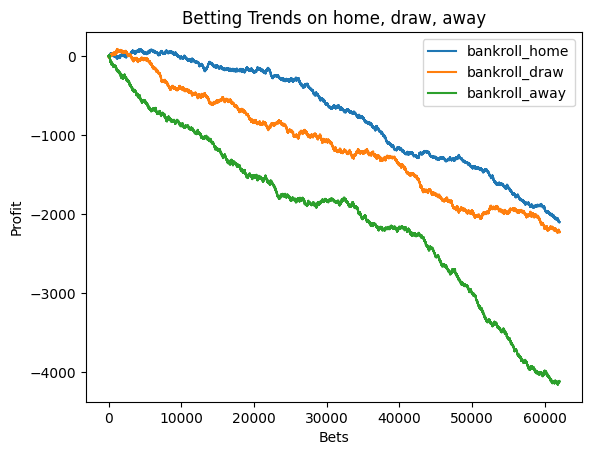

In [17]:
main_df[['bankroll_home', 'bankroll_draw', 'bankroll_away']].plot()

plt.title('Betting Trends on home, draw, away')
plt.xlabel('Bets')
plt.ylabel('Profit')

In [15]:
main_df

,index,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,PSH,PSD,PSA,home_max_odds,draw_max_odds,away_max_odds,pinnacle_true_home_prob,pinnacle_true_draw_prob,pinnacle_true_away_prob,totes,home_ev,bet_size,bankroll_home,bankroll_away,bankroll_draw
0,0,F2,2016-01-08,Amiens,Reims,1.0,1.0,2.91,2.99,2.88,2.91,3.10,2.88,0.335205,0.326010,0.338785,1.0,-0.024554,1.0,-1.00,-1.00,1.99
1,1,E3,2016-01-10,Cambridge,Accrington,2.0,1.0,2.77,3.27,2.80,2.77,3.40,2.80,0.353023,0.297822,0.349155,1.0,-0.022127,1.0,0.77,-2.00,0.99
2,2,E3,2016-01-10,Barnet,Leyton Orient,0.0,0.0,2.66,3.50,2.75,2.66,3.60,2.80,0.367510,0.277284,0.355206,1.0,-0.022424,1.0,-0.23,-3.00,3.49
3,3,F2,2016-01-10,Strasbourg,Valenciennes,2.0,4.0,1.77,3.20,6.30,1.77,3.40,6.30,0.552904,0.300433,0.146663,1.0,-0.021359,1.0,-1.23,2.30,2.49
4,4,I1,2016-01-10,Udinese,Lazio,0.0,3.0,3.12,3.40,2.47,3.13,3.40,2.50,0.314017,0.287621,0.398362,1.0,-0.017128,1.0,-2.23,3.77,1.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62001,62548,E3,2025-12-04,Harrogate,Grimsby,2.0,2.0,3.77,3.35,2.00,3.77,3.40,2.00,0.243999,0.277254,0.478747,1.0,-0.080124,1.0,-2104.30,-4122.56,-2224.71
62002,62549,SP2,2025-12-05,Granada,Eibar,0.0,2.0,1.79,3.44,4.89,1.80,3.44,4.89,0.540707,0.272746,0.186547,1.0,-0.026727,1.0,-2105.30,-4118.67,-2225.71
62003,62550,I1,2025-12-05,Venezia,Fiorentina,2.0,1.0,3.11,3.28,2.46,3.11,3.28,2.46,0.310568,0.293903,0.395529,1.0,-0.034133,1.0,-2103.19,-4119.67,-2226.71
62004,62551,I1,2025-12-05,Atalanta,Roma,2.0,1.0,2.01,3.56,3.91,2.01,3.60,3.91,0.486124,0.269510,0.244366,1.0,-0.022891,1.0,-2102.18,-4120.67,-2227.71
